In [ ]:
!wget http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/facades.tar.gz
!tar -xzf facades.tar.gz

--2026-07-31 11:10:18--  http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/facades.tar.gz
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30168306 (29M) [application/x-gzip]
Saving to: ‘facades.tar.gz’

facades.tar.gz      100%[===================>]  28.77M  6.33MB/s    in 5.6s    

2026-07-31 11:10:23 (5.10 MB/s) - ‘facades.tar.gz’ saved [30168306/30168306]



In [ ]:
!ls facades
!ls facades/train | head -5

test  train  val
100.jpg
101.jpg
102.jpg
103.jpg
104.jpg


In [ ]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms

class FacadesDataset(Dataset):
    def __init__(self, root_dir, image_size=256):
        self.root_dir = root_dir
        self.files = sorted(os.listdir(root_dir))
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.files[idx])
        image = Image.open(img_path).convert("RGB")
        w, h = image.size
        half = w // 2
        input_img = image.crop((half, 0, w, h))
        target_img = image.crop((0, 0, half, h))
        input_img = self.transform(input_img)
        target_img = self.transform(target_img)
        return input_img, target_img


dataset = FacadesDataset(root_dir="facades/train")
print(f"Number of training pairs: {len(dataset)}")

input_img, target_img = dataset[0]
print(f"Input shape: {input_img.shape}")
print(f"Target shape: {target_img.shape}")

Number of training pairs: 400
Input shape: torch.Size([3, 256, 256])
Target shape: torch.Size([3, 256, 256])


In [ ]:
import torch
import torch.nn as nn

class UNetBlock(nn.Module):
    """
    One encoder OR decoder block.
    down=True  -> encoder block (shrinks image)
    down=False -> decoder block (grows image back)
    """
    def __init__(self, in_channels, out_channels, down=True, use_dropout=False):
        super().__init__()
        if down:
            self.conv = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.LeakyReLU(0.2),
            )
        else:
            self.conv = nn.Sequential(
                nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
            )
        self.use_dropout = use_dropout
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.conv(x)
        return self.dropout(x) if self.use_dropout else x


class UNetGenerator(nn.Module):
    """
    Full U-Net generator: encoder -> bottleneck -> decoder, with skip connections
    linking each encoder layer to its matching decoder layer.
    Input:  [batch, 3, 256, 256]
    Output: [batch, 3, 256, 256]
    """
    def __init__(self, in_channels=3, out_channels=3, features=64):
        super().__init__()


        self.down1 = nn.Sequential(
            nn.Conv2d(in_channels, features, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
        )
        self.down2 = UNetBlock(features, features * 2)
        self.down3 = UNetBlock(features * 2, features * 4)
        self.down4 = UNetBlock(features * 4, features * 8)
        self.down5 = UNetBlock(features * 8, features * 8)
        self.down6 = UNetBlock(features * 8, features * 8)
        self.down7 = UNetBlock(features * 8, features * 8)


        self.bottleneck = nn.Sequential(
            nn.Conv2d(features * 8, features * 8, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
        )
        self.up1 = UNetBlock(features * 8, features * 8, down=False, use_dropout=True)
        self.up2 = UNetBlock(features * 8 * 2, features * 8, down=False, use_dropout=True)
        self.up3 = UNetBlock(features * 8 * 2, features * 8, down=False, use_dropout=True)
        self.up4 = UNetBlock(features * 8 * 2, features * 8, down=False)
        self.up5 = UNetBlock(features * 8 * 2, features * 4, down=False)
        self.up6 = UNetBlock(features * 4 * 2, features * 2, down=False)
        self.up7 = UNetBlock(features * 2 * 2, features, down=False)

        self.final_up = nn.Sequential(
            nn.ConvTranspose2d(features * 2, out_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),
        )

    def forward(self, x):

        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        d7 = self.down7(d6)
        bottleneck = self.bottleneck(d7)

        u1 = self.up1(bottleneck)
        u2 = self.up2(torch.cat([u1, d7], dim=1))
        u3 = self.up3(torch.cat([u2, d6], dim=1))
        u4 = self.up4(torch.cat([u3, d5], dim=1))
        u5 = self.up5(torch.cat([u4, d4], dim=1))
        u6 = self.up6(torch.cat([u5, d3], dim=1))
        u7 = self.up7(torch.cat([u6, d2], dim=1))

        return self.final_up(torch.cat([u7, d1], dim=1))


if __name__ == "__main__":

    x = torch.randn(1, 3, 256, 256)
    model = UNetGenerator()
    output = model(x)
    print(f"Input shape:  {x.shape}")
    print(f"Output shape: {output.shape}")

Input shape:  torch.Size([1, 3, 256, 256])
Output shape: torch.Size([1, 3, 256, 256])


In [ ]:
import torch
import torch.nn as nn

class CNNBlock(nn.Module):
    """One conv layer block used inside the discriminator."""
    def __init__(self, in_channels, out_channels, stride=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2),
        )

    def forward(self, x):
        return self.conv(x)


class PatchDiscriminator(nn.Module):
    """
    PatchGAN discriminator.
    Takes the INPUT image and an OUTPUT image (real or fake) concatenated together,
    and produces a grid of real/fake predictions -- one per patch of the image,
    instead of a single real/fake value for the whole image.
    """
    def __init__(self, in_channels=3, features=64):
        super().__init__()


        self.initial = nn.Sequential(
            nn.Conv2d(in_channels * 2, features, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
        )
        self.layer2 = CNNBlock(features, features * 2)
        self.layer3 = CNNBlock(features * 2, features * 4)
        self.layer4 = CNNBlock(features * 4, features * 8, stride=1)


        self.final = nn.Conv2d(features * 8, 1, kernel_size=4, stride=1, padding=1)

    def forward(self, input_img, output_img):
        x = torch.cat([input_img, output_img], dim=1)
        x = self.initial(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.final(x)
        return x
if __name__ == "__main__":

    input_img = torch.randn(1, 3, 256, 256)
    output_img = torch.randn(1, 3, 256, 256)

    model = PatchDiscriminator()
    prediction = model(input_img, output_img)

    print(f"Input image shape:  {input_img.shape}")
    print(f"Output image shape: {output_img.shape}")
    print(f"Discriminator prediction shape: {prediction.shape}")

Input image shape:  torch.Size([1, 3, 256, 256])
Output image shape: torch.Size([1, 3, 256, 256])
Discriminator prediction shape: torch.Size([1, 1, 30, 30])


In [ ]:
import torch
import torch.nn as nn

bce_loss = nn.BCEWithLogitsLoss()
l1_loss = nn.L1Loss()

L1_LAMBDA = 100


def discriminator_loss(disc, input_img, real_target, fake_target):
    real_pred = disc(input_img, real_target)
    real_loss = bce_loss(real_pred, torch.ones_like(real_pred))

    fake_pred = disc(input_img, fake_target.detach())
    fake_loss = bce_loss(fake_pred, torch.zeros_like(fake_pred))

    total_loss = (real_loss + fake_loss) / 2
    return total_loss


def generator_loss(disc, input_img, real_target, fake_target):
    fake_pred = disc(input_img, fake_target)
    adversarial_loss = bce_loss(fake_pred, torch.ones_like(fake_pred))

    pixel_loss = l1_loss(fake_target, real_target)

    total_loss = adversarial_loss + (L1_LAMBDA * pixel_loss)
    return total_loss


gen = UNetGenerator()
disc = PatchDiscriminator()

input_img = torch.randn(1, 3, 256, 256)
real_target = torch.randn(1, 3, 256, 256)

fake_target = gen(input_img)

d_loss = discriminator_loss(disc, input_img, real_target, fake_target)
g_loss = generator_loss(disc, input_img, real_target, fake_target)

print(f"Discriminator loss: {d_loss.item():.4f}")
print(f"Generator loss:     {g_loss.item():.4f}")

Discriminator loss: 0.7108
Generator loss:     95.9897


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.utils as vutils
import os


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LEARNING_RATE = 2e-4
BATCH_SIZE = 16
NUM_EPOCHS = 150
DECAY_START_EPOCH = 75
L1_LAMBDA = 100

os.makedirs("saved_images", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)


dataset = FacadesDataset(root_dir="facades/train")
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = FacadesDataset(root_dir="facades/val")
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=True)


gen = UNetGenerator().to(DEVICE)
disc = PatchDiscriminator().to(DEVICE)


opt_gen = optim.Adam(gen.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))


def lr_lambda(epoch):

    if epoch < DECAY_START_EPOCH:
        return 1.0
    decay_progress = (epoch - DECAY_START_EPOCH) / (NUM_EPOCHS - DECAY_START_EPOCH)
    return max(0.0, 1.0 - decay_progress)


scheduler_gen = optim.lr_scheduler.LambdaLR(opt_gen, lr_lambda=lr_lambda)
scheduler_disc = optim.lr_scheduler.LambdaLR(opt_disc, lr_lambda=lr_lambda)

bce_loss = nn.BCEWithLogitsLoss()
l1_loss = nn.L1Loss()


def save_sample(epoch):
    gen.eval()
    input_img, real_target = next(iter(val_loader))
    input_img, real_target = input_img.to(DEVICE), real_target.to(DEVICE)
    with torch.no_grad():
        fake_target = gen(input_img)
        fake_target = fake_target * 0.5 + 0.5
        input_img_disp = input_img * 0.5 + 0.5
        real_target_disp = real_target * 0.5 + 0.5
        grid = torch.cat([input_img_disp, fake_target, real_target_disp], dim=0)
        vutils.save_image(grid, f"saved_images/epoch_{epoch}.png", nrow=input_img.shape[0])
    gen.train()


def save_checkpoint(epoch):
    torch.save(gen.state_dict(), f"checkpoints/generator_epoch{epoch}.pth")
    torch.save(disc.state_dict(), f"checkpoints/discriminator_epoch{epoch}.pth")


for epoch in range(NUM_EPOCHS):
    for batch_idx, (input_img, real_target) in enumerate(loader):
        input_img, real_target = input_img.to(DEVICE), real_target.to(DEVICE)


        fake_target = gen(input_img)

        real_pred = disc(input_img, real_target)
        fake_pred = disc(input_img, fake_target.detach())
        d_real_loss = bce_loss(real_pred, torch.ones_like(real_pred))
        d_fake_loss = bce_loss(fake_pred, torch.zeros_like(fake_pred))
        d_loss = (d_real_loss + d_fake_loss) / 2

        opt_disc.zero_grad()
        d_loss.backward()
        opt_disc.step()

        fake_pred = disc(input_img, fake_target)
        g_adv_loss = bce_loss(fake_pred, torch.ones_like(fake_pred))
        g_l1_loss = l1_loss(fake_target, real_target) * L1_LAMBDA
        g_loss = g_adv_loss + g_l1_loss

        opt_gen.zero_grad()
        g_loss.backward()
        opt_gen.step()

        if batch_idx % 10 == 0:
            current_lr = opt_gen.param_groups[0]['lr']
            print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Batch [{batch_idx}/{len(loader)}] "
                  f"D_loss: {d_loss.item():.4f} G_loss: {g_loss.item():.4f} LR: {current_lr:.6f}")

    scheduler_gen.step()
    scheduler_disc.step()

    if (epoch + 1) % 5 == 0:
        save_sample(epoch + 1)
        print(f"Saved sample images for epoch {epoch+1}")

    if (epoch + 1) % 25 == 0:
        save_checkpoint(epoch + 1)
        print(f"Saved checkpoint at epoch {epoch+1}")

print("Training finished!")
save_sample(NUM_EPOCHS)
save_checkpoint(NUM_EPOCHS)

Epoch [1/150] Batch [0/25] D_loss: 0.7132 G_loss: 66.7337 LR: 0.000200
Epoch [1/150] Batch [10/25] D_loss: 0.6094 G_loss: 45.9867 LR: 0.000200
Epoch [1/150] Batch [20/25] D_loss: 0.5044 G_loss: 37.9193 LR: 0.000200
Epoch [2/150] Batch [0/25] D_loss: 0.4069 G_loss: 40.8330 LR: 0.000200
Epoch [2/150] Batch [10/25] D_loss: 0.2662 G_loss: 40.2288 LR: 0.000200
Epoch [2/150] Batch [20/25] D_loss: 0.1712 G_loss: 41.3185 LR: 0.000200
Epoch [3/150] Batch [0/25] D_loss: 0.3325 G_loss: 38.1781 LR: 0.000200
Epoch [3/150] Batch [10/25] D_loss: 0.3010 G_loss: 37.3358 LR: 0.000200
Epoch [3/150] Batch [20/25] D_loss: 0.2229 G_loss: 39.8404 LR: 0.000200
Epoch [4/150] Batch [0/25] D_loss: 0.2165 G_loss: 37.5529 LR: 0.000200
Epoch [4/150] Batch [10/25] D_loss: 0.3074 G_loss: 38.9344 LR: 0.000200
Epoch [4/150] Batch [20/25] D_loss: 0.1240 G_loss: 37.0375 LR: 0.000200
Epoch [5/150] Batch [0/25] D_loss: 0.1252 G_loss: 35.6244 LR: 0.000200
Epoch [5/150] Batch [10/25] D_loss: 0.2768 G_loss: 37.1001 LR: 0.0002

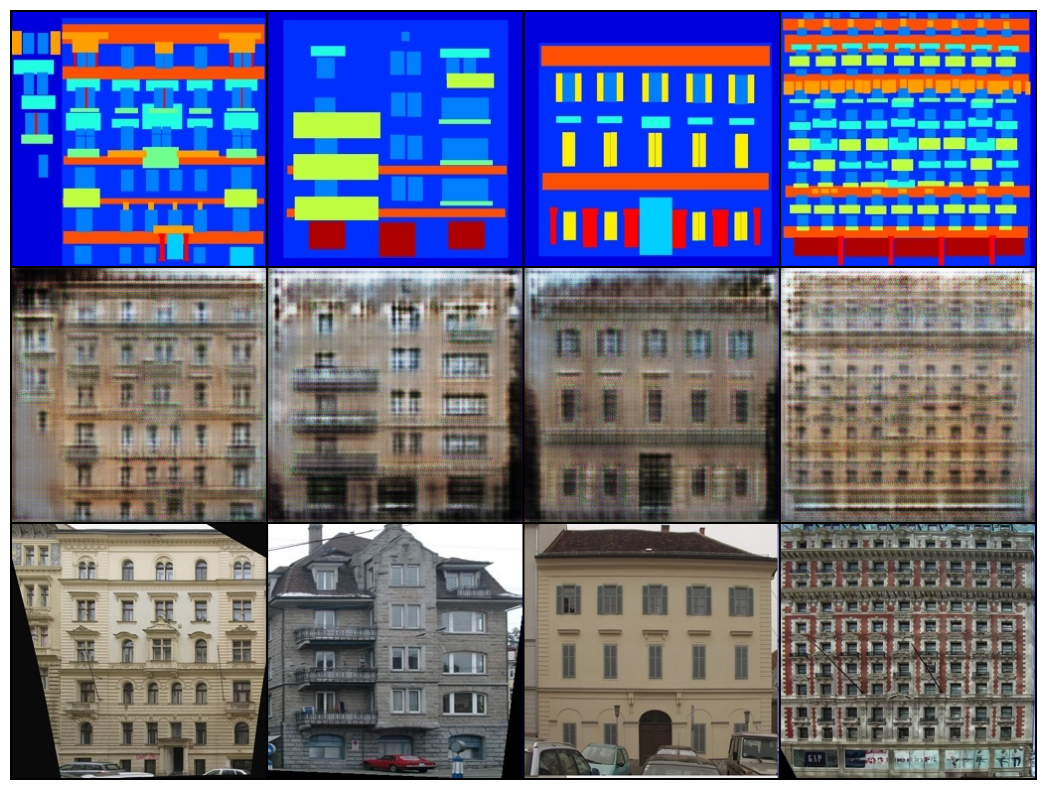

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("saved_images/epoch_20.png")
plt.figure(figsize=(15, 10))
plt.imshow(img)
plt.axis("off")
plt.show()